# Libraries and functions

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_err_vs_norm_all_curves(
    data,
    norm_type="spectral_complexity",
    y_plot="error",
    ax=None,
    figsize=(7, 5),
    lw=1.5,
    alpha=0.9,
    use_log_color=True,
    xscale="linear",
    yscale="linear",
    add_colorbar=True,
    title=None,
    average_seeds=False,
    avg_num_x=200,
    avg_min_count=1,
    return_avg_data=False,
):
    """
    Plot test error (or another observable) versus a chosen norm/time.

    Parameters
    ----------
    data : dict
        Loaded npy dictionary:
        data = np.load(path, allow_pickle=True).item()

    norm_type : str
        "spectral_complexity", "spectral_complexity_no_QK", "l2", "margin_std", or "time"

    y_plot : str
        "error", "spectral_complexity", "spectral_complexity_no_QK", "l2", or "margin_std"

    average_seeds : bool
        If False, plot all seed curves.
        If True, average curves across seeds for each P after interpolation on a
        single global log-spaced x-grid.

    avg_num_x : int
        Number of points in the common x-grid used for averaging.

    avg_min_count : int
        Minimum number of non-NaN seed contributions required at a grid point
        to plot the averaged curve there.

    return_avg_data : bool
        If True, also return a dictionary containing the common grid and the
        averaged/interpolated curves.

    Returns
    -------
    fig, ax
        If return_avg_data is True, also returns avg_data.
    """

    def _get_y_array(data, y_plot):
        if y_plot == "error":
            return np.asarray(data["err_seeds"]), "test error"
        elif y_plot == "train_error":
            return np.asarray(data["trainacc_seeds"]), "train error"
        elif y_plot == "train_loss":
            return np.asarray(data["trainloss_seeds"]), "train loss"
        elif y_plot == "test_loss":
            return np.asarray(data["testloss_seeds"]), "test loss"
        elif y_plot == "spectral_complexity":
            return np.asarray(data["spectral_seeds"]), "spectral complexity norm"
        elif y_plot == "spectral_complexity_no_QK":
            return np.asarray(data["spectral_no_qk_seeds"]), "spectral complexity norm"
        elif y_plot == "l2":
            return np.asarray(data["l2_seeds"]), "L2 norm"
        elif y_plot == "margin_std":
            return np.asarray(data["margin_std_seeds"]), "Margin scale"
        elif y_plot == "margin_mean":
            return np.asarray(data["margin_mean_seeds"]), "Margin mean"
        elif y_plot == "margin_min":
            return np.asarray(data["margin_min_seeds"]), "Margin min"
        elif y_plot == "margin_max":
            return np.asarray(data["margin_max_seeds"]), "Margin max"
        else:
            raise ValueError(
                "y_plot must be one of: "
                "'error', 'spectral_complexity', 'spectral_complexity_no_QK', 'l2', 'margin_std'"
            )

    def _get_x_array(data, norm_type, err_shape, P_values):
        if norm_type == "spectral_complexity":
            return np.asarray(data["spectral_seeds"]), "spectral complexity norm"
        elif norm_type == "spectral_complexity_no_QK":
            return np.asarray(data["spectral_no_qk_seeds"]), "spectral complexity norm"
        elif norm_type == "l2":
            return np.asarray(data["l2_seeds"]), "L2 norm"
        elif norm_type == "margin_std":
            return np.asarray(data["margin_std_seeds"]), "Margin scale"
        elif norm_type == "time":
            t_arr = np.asarray(data["T_arr"])
            x = np.broadcast_to(
                t_arr[None, :, None],
                (err_shape[0], err_shape[1], err_shape[2])
            ).astype(float)
            for iP, P in enumerate(P_values):
                x[iP, :, :] = x[iP, :, :]  / (128.0 / P)
            return x, "t"
        else:
            raise ValueError(
                "norm_type must be one of: "
                "'spectral_complexity', 'spectral_complexity_no_QK', 'l2', 'margin_std', 'time'"
            )

    def _valid_curve(x, y, xscale, yscale, drop_first_n=2):
        x = np.asarray(x, dtype=float)[drop_first_n:]
        y = np.asarray(y, dtype=float)[drop_first_n:]

        mask = np.isfinite(x) & np.isfinite(y)
        if xscale == "log":
            mask &= (x > 0)
        if yscale == "log":
            mask &= (y > 0)

        x = x[mask]
        y = y[mask]

        if x.size < 2:
            return None, None

        # sort by x
        order = np.argsort(x)
        x = x[order]
        y = y[order]

        # remove repeated x values (keep first occurrence)
        x_unique, unique_idx = np.unique(x, return_index=True)
        y_unique = y[unique_idx]

        if x_unique.size < 2:
            return None, None

        return x_unique, y_unique

    def _interp_on_log_grid(x, y, x_grid):
        # interpolate y(x) using log10(x)
        return np.interp(
            np.log10(x_grid),
            np.log10(x),
            y,
            left=np.nan,
            right=np.nan,
        )

    P_values = np.asarray(data["P_values"])
    num_seeds = np.asarray(data["num_seeds"])

    err_seeds, ylabel = _get_y_array(data, y_plot)
    norm_seeds, xlabel = _get_x_array(data, norm_type, err_seeds.shape, P_values)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    cmap = mpl.cm.get_cmap("viridis")

    if len(P_values) == 1:
        def color_of_P(P):
            return cmap(1.0)
        sm = None
    else:
        if use_log_color:
            color_norm = mpl.colors.LogNorm(
                vmin=np.min(P_values),
                vmax=np.max(P_values) + 10000
            )
        else:
            color_norm = mpl.colors.Normalize(
                vmin=np.min(P_values),
                vmax=np.max(P_values)
            )

        def color_of_P(P):
            return cmap(color_norm(P))

        sm = mpl.cm.ScalarMappable(norm=color_norm, cmap=cmap)
        sm.set_array([])

    nP, nT, nS = err_seeds.shape

    avg_data = {
        "P_values": P_values.copy(),
        "x_grid": None,
        "mean_curves": None,
        "counts": None,
        "interpolated_curves": None,
    }

    if not average_seeds:
        for iP in range(nP):
            P = P_values[iP]
            this_color = color_of_P(P)
            for iseed in range(num_seeds[iP]):
                #if iseed == 2:
                x = norm_seeds[iP, :, iseed]
                y = err_seeds[iP, :, iseed]
                x, y = _valid_curve(x, y, xscale, yscale, drop_first_n=2)
                if x is None:
                    continue
                ax.plot(
                    x,
                    y,
                    color=this_color,
                    lw=lw,
                    alpha=alpha,
                )

    else:
        # ---------------------------------------------------------
        # 1) build one global log-spaced x-grid from ALL valid curves
        # ---------------------------------------------------------
        global_x_min = np.inf
        global_x_max = -np.inf

        for iP in range(nP):
            for iseed in range(num_seeds[iP]):
                x = norm_seeds[iP, :, iseed]
                y = err_seeds[iP, :, iseed]

                # for averaging on a log-grid, x must be positive
                x_valid, y_valid = _valid_curve(x, y, "log", yscale, drop_first_n=2)
                if x_valid is None:
                    continue

                global_x_min = min(global_x_min, np.min(x_valid))
                global_x_max = max(global_x_max, np.max(x_valid))

        if not np.isfinite(global_x_min) or not np.isfinite(global_x_max):
            raise ValueError("No valid positive x values found to build the common log-spaced grid.")

        if global_x_min <= 0:
            raise ValueError("Global x-grid for averaging requires strictly positive x values.")

        x_grid = np.logspace(np.log10(global_x_min), np.log10(global_x_max), avg_num_x)

        mean_curves = np.full((nP, avg_num_x), np.nan, dtype=float)
        counts = np.zeros((nP, avg_num_x), dtype=int)
        interpolated_curves = np.full((nP, nS, avg_num_x), np.nan, dtype=float)

        # ---------------------------------------------------------
        # 2) interpolate each seed curve on that common grid
        # 3) average across seeds for each P
        # ---------------------------------------------------------
        for iP in range(nP):
            P = P_values[iP]
            this_color = color_of_P(P)

            interp_list = []

            for iseed in range(num_seeds[iP]):
                x = norm_seeds[iP, :, iseed]
                y = err_seeds[iP, :, iseed]

                x_valid, y_valid = _valid_curve(x, y, "log", yscale, drop_first_n=2)
                if x_valid is None:
                    continue

                y_interp = _interp_on_log_grid(x_valid, y_valid, x_grid)
                interp_list.append(y_interp)
                interpolated_curves[iP, iseed, :] = y_interp

            if len(interp_list) == 0:
                continue

            interp_arr = np.asarray(interp_list)  # shape (n_valid_seeds, avg_num_x)
            mean_curve = np.nanmean(interp_arr, axis=0)
            count_curve = np.sum(np.isfinite(interp_arr), axis=0)

            # require a minimum number of contributing seeds
            mean_curve[count_curve < avg_min_count] = np.nan

            mean_curves[iP, :] = mean_curve
            counts[iP, :] = count_curve

            mask_plot = np.isfinite(mean_curve)
            if np.any(mask_plot):
                ax.plot(
                    x_grid[mask_plot],
                    mean_curve[mask_plot],
                    color=this_color,
                    lw=lw,
                    alpha=alpha,
                )

        avg_data["x_grid"] = x_grid
        avg_data["mean_curves"] = mean_curves
        avg_data["counts"] = counts
        avg_data["interpolated_curves"] = interpolated_curves

    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if title is not None:
        ax.set_title(title)

    if add_colorbar and sm is not None:
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("P")

    plt.tight_layout()

    if return_avg_data:
        return fig, ax, avg_data
    return fig, ax

In [1]:
def two_plots(
    data,
    norm_type="spectral_complexity",
    y_plot_1="error",
    y_plot_2="test_loss",
    ax=None,
    figsize=(7, 5),
    lw=1.5,
    alpha=0.9,
    use_log_color=True,
    xscale="linear",
    yscale="linear",
    add_colorbar=True,
    title=None,
    average_seeds=False,
    avg_num_x=200,
    avg_min_count=1,
    return_avg_data=False,
    add_style_legend=True,
):
    """
    Plot two observables versus the same chosen norm/time on the same axis.

    The first observable is drawn with solid lines, the second with dashed lines.
    Curves with the same P share the same color.

    Parameters
    ----------
    data : dict
        Loaded npy dictionary:
        data = np.load(path, allow_pickle=True).item()

    norm_type : str
        "spectral_complexity", "spectral_complexity_no_QK", "l2", "margin_std", or "time"

    y_plot_1 : str
        First observable (solid).

    y_plot_2 : str
        Second observable (dashed).

    average_seeds : bool
        If False, plot all seed curves.
        If True, average curves across seeds for each P after interpolation on a
        single global log-spaced x-grid.

    avg_num_x : int
        Number of points in the common x-grid used for averaging.

    avg_min_count : int
        Minimum number of non-NaN seed contributions required at a grid point
        to plot the averaged curve there.

    return_avg_data : bool
        If True, also return a dictionary containing the common grid and the
        averaged/interpolated curves for both observables.

    add_style_legend : bool
        If True, add a small legend distinguishing solid vs dashed.

    Returns
    -------
    fig, ax
        If return_avg_data is True, also returns avg_data.
    """

    def _get_y_array(data, y_plot):
        if y_plot == "error":
            return np.asarray(data["err_seeds"]), "test error"
        elif y_plot == "train_error":
            return np.asarray(data["trainacc_seeds"]), "train error"
        elif y_plot == "train_loss":
            return np.asarray(data["trainloss_seeds"]), "train loss"
        elif y_plot == "test_loss":
            return np.asarray(data["testloss_seeds"]), "test loss"
        elif y_plot == "spectral_complexity":
            return np.asarray(data["spectral_seeds"]), "spectral complexity norm"
        elif y_plot == "spectral_complexity_no_QK":
            return np.asarray(data["spectral_no_qk_seeds"]), "spectral complexity norm"
        elif y_plot == "l2":
            return np.asarray(data["l2_seeds"]), "L2 norm"
        elif y_plot == "margin_std":
            return np.asarray(data["margin_std_seeds"]), "Margin scale"
        elif y_plot == "margin_mean":
            return np.asarray(data["margin_mean_seeds"]), "Margin mean"
        elif y_plot == "margin_min":
            return np.asarray(data["margin_min_seeds"]), "Margin min"
        elif y_plot == "margin_max":
            return np.asarray(data["margin_max_seeds"]), "Margin max"
        else:
            raise ValueError(
                "y_plot must be one of: "
                "'error', 'train_loss', 'test_loss', "
                "'spectral_complexity', 'spectral_complexity_no_QK', "
                "'l2', 'margin_std', 'margin_mean', 'margin_min', 'margin_max'"
            )

    def _get_x_array(data, norm_type, ref_shape, P_values):
        if norm_type == "spectral_complexity":
            return np.asarray(data["spectral_seeds"]), "spectral complexity norm"
        elif norm_type == "spectral_complexity_no_QK":
            return np.asarray(data["spectral_no_qk_seeds"]), "spectral complexity norm"
        elif norm_type == "l2":
            return np.asarray(data["l2_seeds"]), "L2 norm"
        elif norm_type == "margin_std":
            return np.asarray(data["margin_std_seeds"]), "Margin scale"
        elif norm_type == "time":
            t_arr = np.asarray(data["T_arr"])
            x = np.broadcast_to(
                t_arr[None, :, None],
                (ref_shape[0], ref_shape[1], ref_shape[2])
            ).astype(float)
            for iP, P in enumerate(P_values):
                x[iP, :, :] = x[iP, :, :] / (128.0 / P)
            return x, "t"
        else:
            raise ValueError(
                "norm_type must be one of: "
                "'spectral_complexity', 'spectral_complexity_no_QK', 'l2', 'margin_std', 'time'"
            )

    def _valid_curve(x, y, xscale, yscale, drop_first_n=2):
        x = np.asarray(x, dtype=float)[drop_first_n:]
        y = np.asarray(y, dtype=float)[drop_first_n:]

        mask = np.isfinite(x) & np.isfinite(y)
        if xscale == "log":
            mask &= (x > 0)
        if yscale == "log":
            mask &= (y > 0)

        x = x[mask]
        y = y[mask]

        if x.size < 2:
            return None, None

        order = np.argsort(x)
        x = x[order]
        y = y[order]

        x_unique, unique_idx = np.unique(x, return_index=True)
        y_unique = y[unique_idx]

        if x_unique.size < 2:
            return None, None

        return x_unique, y_unique

    def _interp_on_log_grid(x, y, x_grid):
        return np.interp(
            np.log10(x_grid),
            np.log10(x),
            y,
            left=np.nan,
            right=np.nan,
        )

    def _collect_global_x_range(x_all, y_all_list, num_seeds, nP, yscale):
        global_x_min = np.inf
        global_x_max = -np.inf

        for iP in range(nP):
            for iseed in range(num_seeds[iP]):
                x = x_all[iP, :, iseed]

                found_valid = False
                for y_all in y_all_list:
                    y = y_all[iP, :, iseed]
                    x_valid, y_valid = _valid_curve(x, y, "log", yscale, drop_first_n=2)
                    if x_valid is None:
                        continue
                    global_x_min = min(global_x_min, np.min(x_valid))
                    global_x_max = max(global_x_max, np.max(x_valid))
                    found_valid = True

        if not np.isfinite(global_x_min) or not np.isfinite(global_x_max):
            raise ValueError("No valid positive x values found to build the common log-spaced grid.")

        if global_x_min <= 0:
            raise ValueError("Global x-grid for averaging requires strictly positive x values.")

        return global_x_min, global_x_max

    P_values = np.asarray(data["P_values"])
    num_seeds = np.asarray(data["num_seeds"])

    y1_seeds, ylabel1 = _get_y_array(data, y_plot_1)
    y2_seeds, ylabel2 = _get_y_array(data, y_plot_2)
    x_seeds, xlabel = _get_x_array(data, norm_type, y1_seeds.shape, P_values)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    cmap = mpl.cm.get_cmap("viridis")

    if len(P_values) == 1:
        def color_of_P(P):
            return cmap(1.0)
        sm = None
    else:
        if use_log_color:
            color_norm = mpl.colors.LogNorm(
                vmin=np.min(P_values),
                vmax=np.max(P_values) + 10000
            )
        else:
            color_norm = mpl.colors.Normalize(
                vmin=np.min(P_values),
                vmax=np.max(P_values)
            )

        def color_of_P(P):
            return cmap(color_norm(P))

        sm = mpl.cm.ScalarMappable(norm=color_norm, cmap=cmap)
        sm.set_array([])

    nP, nT, nS = y1_seeds.shape

    avg_data = {
        "P_values": P_values.copy(),
        "x_grid": None,

        "mean_curves_1": None,
        "counts_1": None,
        "interpolated_curves_1": None,

        "mean_curves_2": None,
        "counts_2": None,
        "interpolated_curves_2": None,
    }

    if not average_seeds:
        for iP in range(nP):
            P = P_values[iP]
            this_color = color_of_P(P)

            for iseed in range(num_seeds[iP]):
                x = x_seeds[iP, :, iseed]

                y1 = y1_seeds[iP, :, iseed]
                x1, yy1 = _valid_curve(x, y1, xscale, yscale, drop_first_n=2)
                if x1 is not None:
                    ax.plot(
                        x1,
                        yy1,
                        color=this_color,
                        lw=lw,
                        alpha=alpha,
                        ls="-",
                    )

                y2 = y2_seeds[iP, :, iseed]
                x2, yy2 = _valid_curve(x, y2, xscale, yscale, drop_first_n=2)
                if x2 is not None:
                    ax.plot(
                        x2,
                        yy2,
                        color=this_color,
                        lw=lw,
                        alpha=alpha,
                        ls="--",
                    )

    else:
        # one common log-spaced x-grid for both observables
        global_x_min, global_x_max = _collect_global_x_range(
            x_seeds,
            [y1_seeds, y2_seeds],
            num_seeds,
            nP,
            yscale
        )

        x_grid = np.logspace(np.log10(global_x_min), np.log10(global_x_max), avg_num_x)

        mean_curves_1 = np.full((nP, avg_num_x), np.nan, dtype=float)
        counts_1 = np.zeros((nP, avg_num_x), dtype=int)
        interpolated_curves_1 = np.full((nP, nS, avg_num_x), np.nan, dtype=float)

        mean_curves_2 = np.full((nP, avg_num_x), np.nan, dtype=float)
        counts_2 = np.zeros((nP, avg_num_x), dtype=int)
        interpolated_curves_2 = np.full((nP, nS, avg_num_x), np.nan, dtype=float)

        for iP in range(nP):
            P = P_values[iP]
            this_color = color_of_P(P)

            interp_list_1 = []
            interp_list_2 = []

            for iseed in range(num_seeds[iP]):
                x = x_seeds[iP, :, iseed]

                # first observable
                y1 = y1_seeds[iP, :, iseed]
                x1, yy1 = _valid_curve(x, y1, "log", yscale, drop_first_n=2)
                if x1 is not None:
                    y1_interp = _interp_on_log_grid(x1, yy1, x_grid)
                    interp_list_1.append(y1_interp)
                    interpolated_curves_1[iP, iseed, :] = y1_interp

                # second observable
                y2 = y2_seeds[iP, :, iseed]
                x2, yy2 = _valid_curve(x, y2, "log", yscale, drop_first_n=2)
                if x2 is not None:
                    y2_interp = _interp_on_log_grid(x2, yy2, x_grid)
                    interp_list_2.append(y2_interp)
                    interpolated_curves_2[iP, iseed, :] = y2_interp

            # average first observable
            if len(interp_list_1) > 0:
                interp_arr_1 = np.asarray(interp_list_1)
                mean_curve_1 = np.nanmean(interp_arr_1, axis=0)
                count_curve_1 = np.sum(np.isfinite(interp_arr_1), axis=0)
                mean_curve_1[count_curve_1 < avg_min_count] = np.nan

                mean_curves_1[iP, :] = mean_curve_1
                counts_1[iP, :] = count_curve_1

                mask_plot_1 = np.isfinite(mean_curve_1)
                if np.any(mask_plot_1):
                    ax.plot(
                        x_grid[mask_plot_1],
                        mean_curve_1[mask_plot_1],
                        color=this_color,
                        lw=lw,
                        alpha=alpha,
                        ls="-",
                    )

            # average second observable
            if len(interp_list_2) > 0:
                interp_arr_2 = np.asarray(interp_list_2)
                mean_curve_2 = np.nanmean(interp_arr_2, axis=0)
                count_curve_2 = np.sum(np.isfinite(interp_arr_2), axis=0)
                mean_curve_2[count_curve_2 < avg_min_count] = np.nan

                mean_curves_2[iP, :] = mean_curve_2
                counts_2[iP, :] = count_curve_2

                mask_plot_2 = np.isfinite(mean_curve_2)
                if np.any(mask_plot_2):
                    ax.plot(
                        x_grid[mask_plot_2],
                        mean_curve_2[mask_plot_2],
                        color=this_color,
                        lw=lw,
                        alpha=alpha,
                        ls="--",
                    )

        avg_data["x_grid"] = x_grid

        avg_data["mean_curves_1"] = mean_curves_1
        avg_data["counts_1"] = counts_1
        avg_data["interpolated_curves_1"] = interpolated_curves_1

        avg_data["mean_curves_2"] = mean_curves_2
        avg_data["counts_2"] = counts_2
        avg_data["interpolated_curves_2"] = interpolated_curves_2

    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(f"{ylabel1} / {ylabel2}", fontsize=16)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if title is not None:
        ax.set_title(title)

    if add_colorbar and sm is not None:
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("P")

    if add_style_legend:
        style_handles = [
            mpl.lines.Line2D([], [], color="black", lw=lw, ls="-", label=ylabel1),
            mpl.lines.Line2D([], [], color="black", lw=lw, ls="--", label=ylabel2),
        ]
        ax.legend(handles=style_handles, frameon=False)

    plt.tight_layout()

    if return_avg_data:
        return fig, ax, avg_data
    return fig, ax

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def _power_law_no_offset(x, k, gamma):
    return k * x**gamma


def _power_law_with_offset(x, k, gamma, q):
    return k * x**gamma + q


def _fit_power_law_no_offset(x, y, min_points=3):
    """
    Fit y = k * x^gamma in log-log scale.
    Returns k, gamma.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    if x.size < min_points:
        return np.nan, np.nan

    gamma, logk = np.polyfit(np.log(x), np.log(y), 1)
    k = np.exp(logk)
    return k, gamma


def _safe_nanargmin(y):
    """
    Return argmin among finite values, or None if no finite values exist.
    """
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(y)
    if not np.any(mask):
        return None
    idx_valid = np.where(mask)[0]
    return idx_valid[np.argmin(y[mask])]


def _get_x_curve_from_avg(avg_data, i_p):
    """
    avg_data["x_grid"] can be:
      - shape (nX,)  : same grid for all P
      - shape (nP,nX): one grid per P
    """
    x_grid = np.asarray(avg_data["x_grid"], dtype=float)

    if x_grid.ndim == 1:
        return x_grid.copy()
    elif x_grid.ndim == 2:
        return x_grid[i_p].copy()
    else:
        raise ValueError('avg_data["x_grid"] must be 1D or 2D.')


def plot_three_fits_from_avg(
    avg_data,
    alpha_arr=None,
    p_start=0,
    p_end=None,
    xfit_min=1.0,
    xfit_max=np.inf,
    branch="right",
    fit_eps_measured_with_offset=False,
    x_label="norm",
    y_label=r"$\epsilon$",
    figsize=(18, 5),
    size_font=16,
    min_points=3,
    theory_gamma1=None,
    theory_gamma2=None,
):
    """
    Make the three plots using the averaged curves returned by
    plot_err_vs_norm_all_curves(..., average_seeds=True, return_avg_data=True).

    Parameters
    ----------
    avg_data : dict
        Dictionary returned by the first function. Must contain:
            - "P_values"
            - "x_grid"
            - "mean_curves"

    alpha_arr : array-like, optional
        Alpha values corresponding to each P.
        If None, alpha_arr = avg_data["P_values"].

    p_start, p_end : int
        First and last indices of curves to use in the FIRST plot only.

    xfit_min, xfit_max : float
        Fit window in rescaled variable x / x_opt for the FIRST plot only.

    branch : {"right", "left", "both"}
        Which side of the minimum to use in the FIRST plot only.

    fit_eps_measured_with_offset : bool
        If True, fit eps_opt(alpha) with k * alpha^gamma + q.
        If False, fit eps_opt(alpha) with k * alpha^gamma.

    x_label : str
        Label of the x-variable used in the curves.

    y_label : str
        Label of the y-variable.

    theory_gamma1, theory_gamma2 : float or None
        Optional theoretical values to show in the titles.
    """

    P_arr = np.asarray(avg_data["P_values"], dtype=float)
    mean_curves = np.asarray(avg_data["mean_curves"], dtype=float)

    if mean_curves.ndim != 2:
        raise ValueError('avg_data["mean_curves"] must have shape (nP, nX).')

    nP, nX = mean_curves.shape

    if alpha_arr is None:
        alpha_arr = P_arr.copy()
    else:
        alpha_arr = np.asarray(alpha_arr, dtype=float)

    if alpha_arr.shape[0] != nP:
        raise ValueError("alpha_arr must have the same length as P_values.")

    if p_end is None:
        p_end = nP - 1

    if not (0 <= p_start <= p_end < nP):
        raise ValueError("Invalid p_start / p_end range.")

    sel = np.arange(p_start, p_end + 1)

    # ------------------------------------------------------------
    # minima of averaged curves: x_opt(P), eps_opt(P)
    # ------------------------------------------------------------
    idx_min_all_full = np.full(nP, -1, dtype=int)
    eps_opt_full = np.full(nP, np.nan, dtype=float)
    x_opt_full = np.full(nP, np.nan, dtype=float)

    for i_p in range(nP):
        x = _get_x_curve_from_avg(avg_data, i_p)
        y = mean_curves[i_p]

        idx_min = _safe_nanargmin(y)
        if idx_min is None:
            continue

        if not np.isfinite(x[idx_min]):
            continue

        idx_min_all_full[i_p] = idx_min
        eps_opt_full[i_p] = y[idx_min]
        x_opt_full[i_p] = x[idx_min]

    alpha_full = alpha_arr.copy()

    fig, axs = plt.subplots(1, 3, figsize=figsize)

    # ============================
    # 1) Rescaled curves and gamma1
    # ============================
    ax = axs[0]
    curve_fit_params = []

    X_pool = []
    Y_pool = []

    for i_p in sel:
        x = _get_x_curve_from_avg(avg_data, i_p)
        eps = mean_curves[i_p]

        idx_min = idx_min_all_full[i_p]
        if idx_min < 0:
            continue

        eps_min = eps[idx_min]
        x_min = x[idx_min]

        if not (np.isfinite(eps_min) and np.isfinite(x_min) and x_min > 0 and eps_min > 0):
            continue

        x_res = x / x_min
        y_res = eps / eps_min

        mask_plot = np.isfinite(x_res) & np.isfinite(y_res) & (x_res > 0) & (y_res > 0)

        mask_fit = mask_plot.copy()
        mask_fit &= (x_res >= xfit_min) & (x_res <= xfit_max)

        if branch == "right":
            mask_fit &= (np.arange(len(x_res)) >= idx_min)
        elif branch == "left":
            mask_fit &= (np.arange(len(x_res)) <= idx_min)
        elif branch == "both":
            pass
        else:
            raise ValueError("branch must be 'right', 'left', or 'both'.")

        k1_i, gamma1_i = _fit_power_law_no_offset(
            x_res[mask_fit], y_res[mask_fit], min_points=min_points
        )

        curve_fit_params.append({
            "P": P_arr[i_p],
            "alpha": alpha_arr[i_p],
            "k1": k1_i,
            "gamma1": gamma1_i,
            "idx_min": idx_min,
            "eps_min": eps_min,
            "x_min": x_min,
        })

        line, = ax.plot(
            x_res[mask_plot],
            y_res[mask_plot],
            marker="o",
            ms=3,
            lw=1,
            label=fr"$P={P_arr[i_p]:.0f}$"
        )

        if np.isfinite(k1_i) and np.isfinite(gamma1_i) and np.sum(mask_fit) >= min_points:
            x_fit = np.logspace(
                np.log10(np.min(x_res[mask_fit])),
                np.log10(np.max(x_res[mask_fit])),
                200
            )
            y_fit = _power_law_no_offset(x_fit, k1_i, gamma1_i)
            ax.plot(
                x_fit,
                y_fit,
                "--",
                lw=2,
                color=line.get_color(),
            )

            X_pool.append(x_res[mask_fit])
            Y_pool.append(y_res[mask_fit])

    if len(X_pool) > 0:
        X_pool = np.concatenate(X_pool)
        Y_pool = np.concatenate(Y_pool)
        k1_global, gamma1_global = _fit_power_law_no_offset(
            X_pool, Y_pool, min_points=min_points
        )

        if np.isfinite(k1_global) and np.isfinite(gamma1_global):
            x_fit_global = np.logspace(
                np.log10(np.min(X_pool)),
                np.log10(np.max(X_pool)),
                300
            )
            y_fit_global = _power_law_no_offset(x_fit_global, k1_global, gamma1_global)
            ax.plot(
                x_fit_global,
                y_fit_global,
                "k-",
                lw=3,
                label=fr"pooled fit: $k_1={k1_global:.3e}$, $\gamma_1={gamma1_global:.3f}$"
            )
    else:
        k1_global, gamma1_global = np.nan, np.nan

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(rf"${x_label} / {x_label}_{{\rm opt}}$", fontsize=size_font)
    ax.set_ylabel(rf"{y_label}" + r"$ / " + y_label.strip("$") + r"_{\rm opt}$", fontsize=size_font)

    if theory_gamma1 is None:
        ax.set_title(r"Rescaled averaged curves", fontsize=size_font)
    else:
        ax.set_title(
            rf"Rescaled averaged curves, $\gamma_1^*={theory_gamma1:.3f}$",
            fontsize=size_font
        )

    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=9)

    # ============================
    # 2) x_opt(alpha) and gamma2
    # ============================
    ax = axs[1]

    mask2 = (
        np.isfinite(alpha_full) & (alpha_full > 0) &
        np.isfinite(x_opt_full) & (x_opt_full > 0) 
    )

    ax.plot(alpha_full[mask2], x_opt_full[mask2], "o", ms=5, label="measured minima")

    k2, gamma2 = _fit_power_law_no_offset(
        alpha_full[mask2], x_opt_full[mask2], min_points=min_points
    )
    q2 = 0.0

    if np.sum(mask2) >= 2:
        alpha_plot = np.logspace(
            np.log10(np.min(alpha_full[mask2])),
            np.log10(np.max(alpha_full[mask2])),
            400
        )
    else:
        alpha_plot = np.array([])

    if np.isfinite(k2) and np.isfinite(gamma2) and alpha_plot.size > 0:
        x_fit = _power_law_with_offset(alpha_plot, k2, gamma2, q2)
        mask_pos = np.isfinite(x_fit) & (x_fit > 0)
        ax.plot(
            alpha_plot[mask_pos],
            x_fit[mask_pos],
            "-",
            lw=2,
            label=fr"fit: $k_2={k2:.3e}$, $\gamma_2={gamma2:.3f}$"
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$P$", fontsize=size_font)
    ax.set_ylabel(rf"${x_label}_{{\rm opt}}$", fontsize=size_font)

    if theory_gamma2 is None:
        ax.set_title(rf"Fit of ${{{x_label}}}_{{\rm opt}}(P)$", fontsize=size_font)
    else:
        ax.set_title(
            rf"Fit of ${{{x_label}}}_{{\rm opt}}(P)$, $\gamma_2^*={theory_gamma2:.3f}$",
            fontsize=size_font
        )

    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=10)

    # ============================
    # 3) eps_opt(alpha): measured vs predicted
    # ============================
    ax = axs[2]

    mask3 = (
        np.isfinite(alpha_full) & (alpha_full > 0) &
        np.isfinite(eps_opt_full) & (eps_opt_full > 0)
    )

    ax.plot(alpha_full[mask3], eps_opt_full[mask3], "o", ms=5,
            label=rf"measured {y_label}_{{\rm opt}}")

    if fit_eps_measured_with_offset:
        k0e, gamma0e = _fit_power_law_no_offset(
            alpha_full[mask3], eps_opt_full[mask3], min_points=min_points
        )
        if not np.isfinite(k0e):
            k0e = 1.0
        if not np.isfinite(gamma0e):
            gamma0e = 0.0
        q0e = 0.0

        try:
            popt_eps, _ = curve_fit(
                _power_law_with_offset,
                alpha_full[mask3],
                eps_opt_full[mask3],
                p0=[k0e, gamma0e, q0e],
                bounds=([0.0, -np.inf, -np.inf], [np.inf, np.inf, np.inf]),
                maxfev=20000,
            )
            k_meas, gamma_meas, q_meas = popt_eps
            eps_meas_fit = _power_law_with_offset(alpha_plot, k_meas, gamma_meas, q_meas)
            mask_pos = np.isfinite(eps_meas_fit) & (eps_meas_fit > 0)
            ax.plot(
                alpha_plot[mask_pos],
                eps_meas_fit[mask_pos],
                "--",
                lw=2,
                label=fr"measured fit: $\gamma_{{\rm meas}}={gamma_meas:.3f}$, $q={q_meas:.3e}$"
            )
        except Exception:
            k_meas, gamma_meas, q_meas = np.nan, np.nan, np.nan
    else:
        k_meas, gamma_meas = _fit_power_law_no_offset(
            alpha_full[mask3], eps_opt_full[mask3], min_points=min_points
        )
        q_meas = 0.0
        if np.isfinite(k_meas) and np.isfinite(gamma_meas) and alpha_plot.size > 0:
            eps_meas_fit = _power_law_no_offset(alpha_plot, k_meas, gamma_meas)
            ax.plot(
                alpha_plot,
                eps_meas_fit,
                "--",
                lw=2,
                label=fr"measured fit: $k={k_meas:.3e}$, $\gamma_{{\rm meas}}={gamma_meas:.3f}$"
            )

    if (
        np.isfinite(k1_global) and np.isfinite(gamma1_global) and
        np.isfinite(k2) and np.isfinite(gamma2) and alpha_plot.size > 0
    ):
        inner = _power_law_with_offset(alpha_plot, k2, gamma2, q2)
        mask_pred = np.isfinite(inner) & (inner > 0)

        eps_pred = np.full_like(alpha_plot, np.nan, dtype=float)
        eps_pred[mask_pred] = k1_global * inner[mask_pred]**gamma1_global

        mask_plot = np.isfinite(eps_pred) & (eps_pred > 0)
        ax.plot(
            alpha_plot[mask_plot],
            eps_pred[mask_plot],
            "-",
            lw=2,
            label=fr"predicted: $\gamma_1\gamma_2={gamma1_global * gamma2:.3f}$"
        )

        gamma_pred = gamma1_global * gamma2
    else:
        gamma_pred = np.nan

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$P$", fontsize=size_font)
    ax.set_ylabel(rf"${y_label.strip('$')}_{{\rm opt}}$", fontsize=size_font)
    ax.set_title(rf"${y_label.strip('$')}_{{\rm opt}}(P)$: measured vs predicted", fontsize=size_font)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n--- Per-curve fits of rescaled averaged curves (selected range only) ---")
    for d in curve_fit_params:
        print(
            f"P={d['P']:.0f}, alpha={d['alpha']:.6g}, "
            f"k1={d['k1']:.6e}, gamma1={d['gamma1']:.6f}"
        )

    print("\n--- Pooled fit of rescaled averaged curves (selected range only) ---")
    print(f"k1_global     = {k1_global:.6e}")
    print(f"gamma1_global = {gamma1_global:.6f}")

    print("\n--- Fit of x_opt(alpha) (ALL data) ---")
    print(f"k2     = {k2:.6e}")
    print(f"gamma2 = {gamma2:.6f}")
    print(f"q2     = {q2:.6e}")

    print("\n--- Fit of eps_opt(alpha) (ALL data) ---")
    print(f"k_meas     = {k_meas:.6e}")
    print(f"gamma_meas = {gamma_meas:.6f}")
    print(f"q_meas     = {q_meas:.6e}")

    print("\n--- Exponent comparison ---")
    print(f"gamma_meas = {gamma_meas:.6f}")
    print(f"gamma_pred = gamma1_global * gamma2 = {gamma_pred:.6f}")

    return {
        "curve_fit_params": curve_fit_params,
        "k1_global": k1_global,
        "gamma1_global": gamma1_global,
        "k2": k2,
        "gamma2": gamma2,
        "q2": q2,
        "k_meas": k_meas,
        "gamma_meas": gamma_meas,
        "q_meas": q_meas,
        "gamma_pred": gamma_pred,
        "alpha_full": alpha_full,
        "eps_opt_full": eps_opt_full,
        "x_opt_full": x_opt_full,
        "idx_min_all_full": idx_min_all_full,
    }

# RHM uniform, L=4

In [4]:
res = np.load("results/L4_v2.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'timestep_values', 'T_arr_timestep', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'trainacc_raw', 'trainerr_raw', 'testloss_raw', 'testacc_raw', 'err_raw', 'spectral_raw', 'spectral_no_qk_raw', 'l2_raw', 'margin_min_raw', 'margin_mean_raw', 'margin_max_raw', 'margin_std_raw', 'trainloss_timestep_raw', 'trainacc_timestep_raw', 'trainerr_timestep_raw', 'testloss_timestep_raw', 'testacc_timestep_raw', 'err_timestep_raw', 'spectral_timestep_raw', 'spectral_no_qk_timestep_raw', 'l2_timestep_raw', 'margin_min_timestep_raw', 'margin_mean_timestep_raw', 'margin_max_timestep_raw', 'margin_std_timestep_raw', 'trainloss_seeds', 'trainacc_seeds', 'trainerr_seeds', 'testloss_seeds', 'testacc_seeds', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_seeds', 'l2_seeds', 'margin_min_seeds', 'margin_mean_seeds', 'margin_max_seeds', 'margin_std_seeds', 'trainloss_seeds_timestep', 'trainacc_seeds_timestep', 'tra

[2.34057143e+03 3.74491429e+04 5.99186286e+05 9.58698057e+06]
[  2340.57142857   9362.28571429  37449.14285714 149796.57142857]


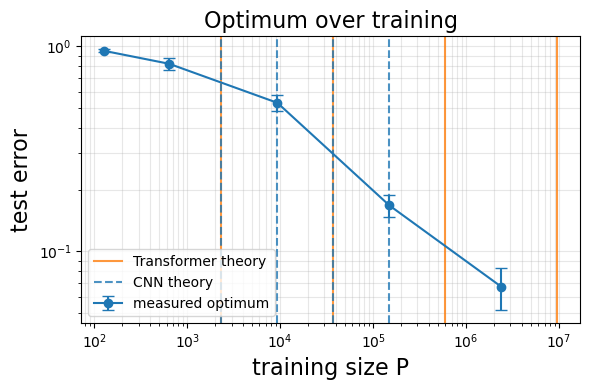

In [5]:
import numpy as np
import matplotlib.pyplot as plt

P = np.asarray(res["P_values"], dtype=float)
y = np.asarray(res["best_acc_mean"], dtype=float)
yerr = np.asarray(res["best_acc_std"], dtype=float)
yerr = np.where(yerr < 0, 0.0, yerr)

# ---- extract actual RHM parameters from res ----
fp = res.get("fixed_params", {})

v = 32
m = 4
s = 2
L = 4


f = m / (v ** (s - 1))
if not (0 < f < 1):
    raise ValueError(f"Need 0 < f = m / v^(s-1) < 1, got f={f:.6g}")

levels = np.arange(1, L + 1)

# Paper predictions
P_tr = (v / (1 - f)) * (m ** (2 * levels + 1))   # transformer
P_cnn = (v / (1 - f)) * (m ** (levels + 2))      # CNN
print(P_tr)
print(P_cnn)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(P, 1 - y, yerr=yerr, marker="o", capsize=4, label="measured optimum")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("training size P", fontsize=16)
ax.set_ylabel("test error", fontsize=16)
ax.set_title("Optimum over training", fontsize=16)
ax.grid(True, which="both", alpha=0.3)

# vertical lines: transformer thresholds
for i, pth in enumerate(P_tr):
    ax.axvline(
        pth,
        color="tab:orange",
        ls="-",
        lw=1.5,
        alpha=0.8,
        label="Transformer theory" if i == 0 else None,
    )

# vertical lines: CNN thresholds
for i, pth in enumerate(P_cnn):
    ax.axvline(
        pth,
        color="tab:blue",
        ls="--",
        lw=1.5,
        alpha=0.8,
        label="CNN theory" if i == 0 else None,
    )

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipykernel_6096/2573711242.py:165: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_6096/2573711242.py:276: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

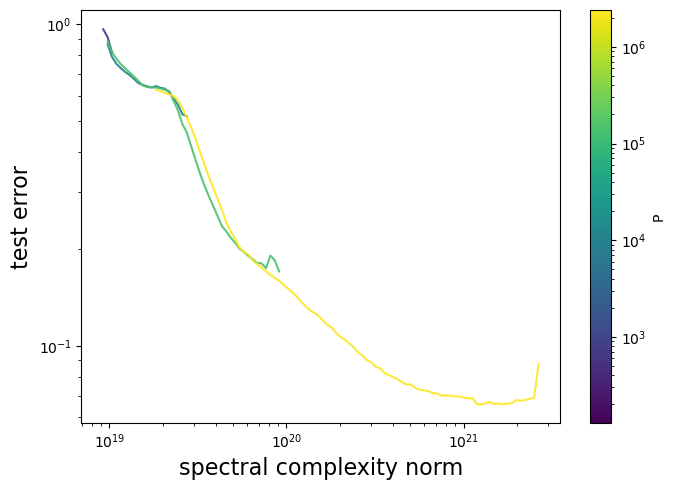

In [43]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_20079/2573711242.py:165: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_20079/2573711242.py:276: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

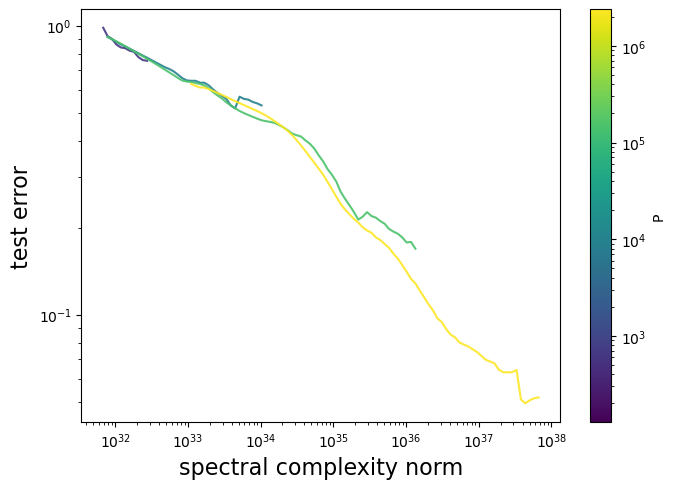

In [12]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_20079/2866105030.py:197: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_20079/2866105030.py:317: RuntimeWarning: Mean of empty slice
  mean_curve_1 = np.nanmean(interp_arr_1, axis=0)
/tmp/ipykernel_20079/2866105030.py:338: RuntimeWarning: Mean of empty slice
  mean_curve_2 = np.nanmean(interp_arr_2, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test loss / train loss'>)

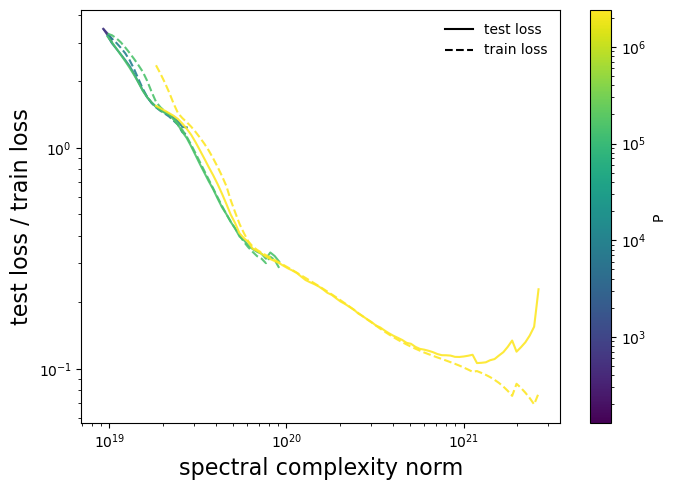

In [6]:
two_plots(
    res,
    y_plot_1 = "test_loss",
    y_plot_2 = "train_loss",
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_20079/2866105030.py:197: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_20079/2866105030.py:317: RuntimeWarning: Mean of empty slice
  mean_curve_1 = np.nanmean(interp_arr_1, axis=0)
/tmp/ipykernel_20079/2866105030.py:338: RuntimeWarning: Mean of empty slice
  mean_curve_2 = np.nanmean(interp_arr_2, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test loss / train loss'>)

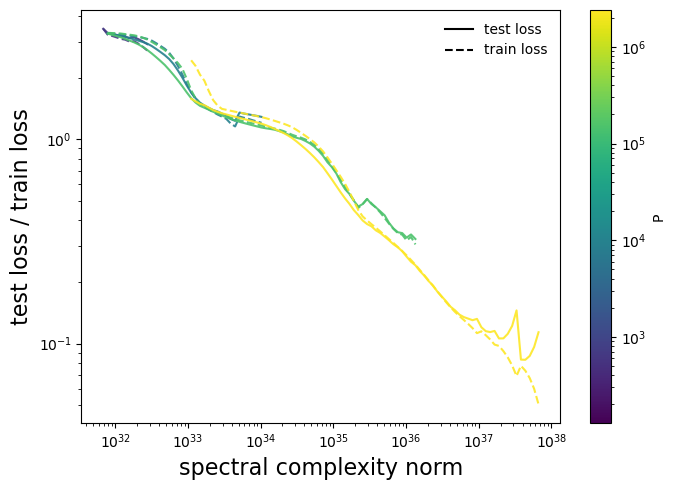

In [13]:
two_plots(
    res,
    y_plot_1 = "test_loss",
    y_plot_2 = "train_loss",
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_20079/2866105030.py:197: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_20079/2866105030.py:317: RuntimeWarning: Mean of empty slice
  mean_curve_1 = np.nanmean(interp_arr_1, axis=0)
/tmp/ipykernel_20079/2866105030.py:338: RuntimeWarning: Mean of empty slice
  mean_curve_2 = np.nanmean(interp_arr_2, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='L2 norm', ylabel='test loss / train loss'>)

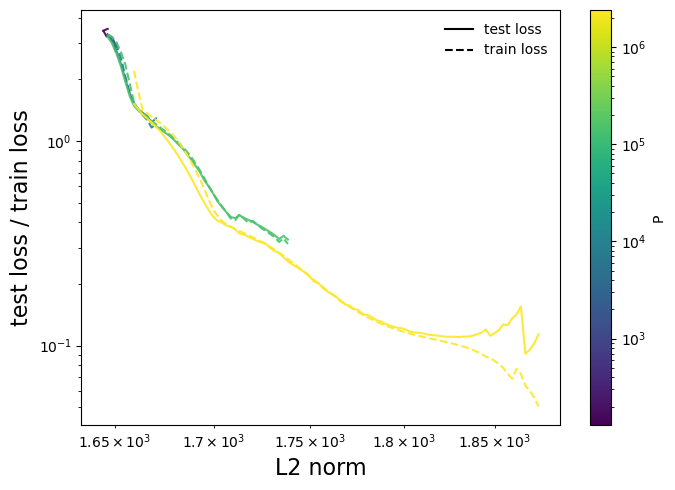

In [7]:
two_plots(
    res,
    y_plot_1 = "test_loss",
    y_plot_2 = "train_loss",
    norm_type="l2",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_6096/2866105030.py:197: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_6096/2866105030.py:317: RuntimeWarning: Mean of empty slice
  mean_curve_1 = np.nanmean(interp_arr_1, axis=0)
/tmp/ipykernel_6096/2866105030.py:338: RuntimeWarning: Mean of empty slice
  mean_curve_2 = np.nanmean(interp_arr_2, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='test loss / train loss'>)

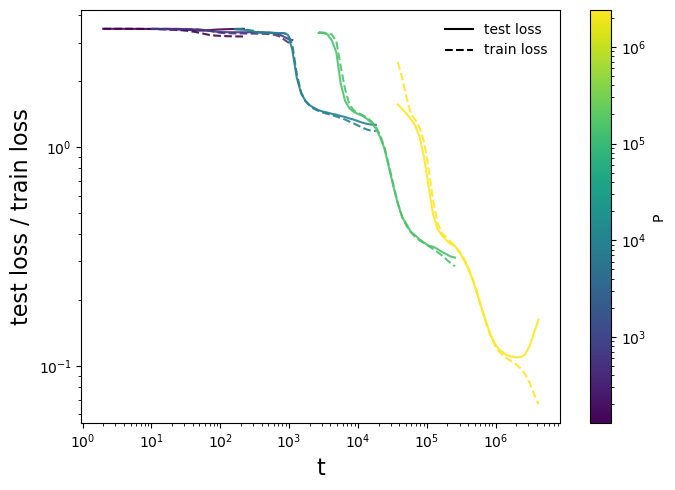

In [40]:
two_plots(
    res,
    y_plot_1 = "test_loss",
    y_plot_2 = "train_loss",
    norm_type="time",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_6096/2866105030.py:197: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_6096/2866105030.py:317: RuntimeWarning: Mean of empty slice
  mean_curve_1 = np.nanmean(interp_arr_1, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='test error / train error'>)

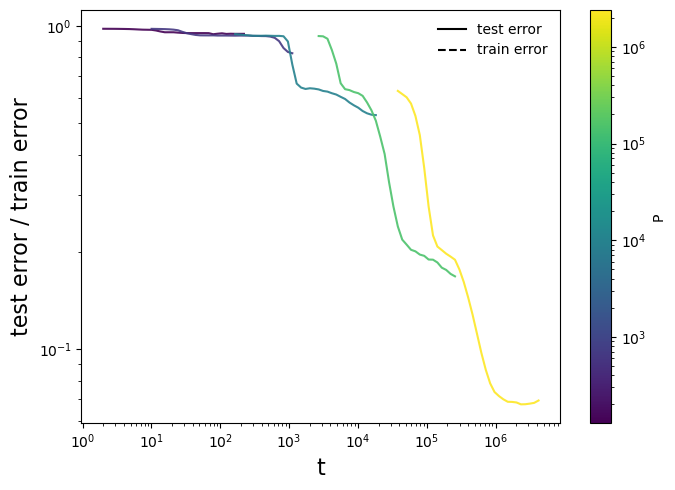

In [44]:
two_plots(
    res,
    y_plot_1 = "error",
    y_plot_2 = "train_error",
    norm_type="time",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_6096/2573711242.py:165: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_6096/2573711242.py:276: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='spectral complexity norm'>)

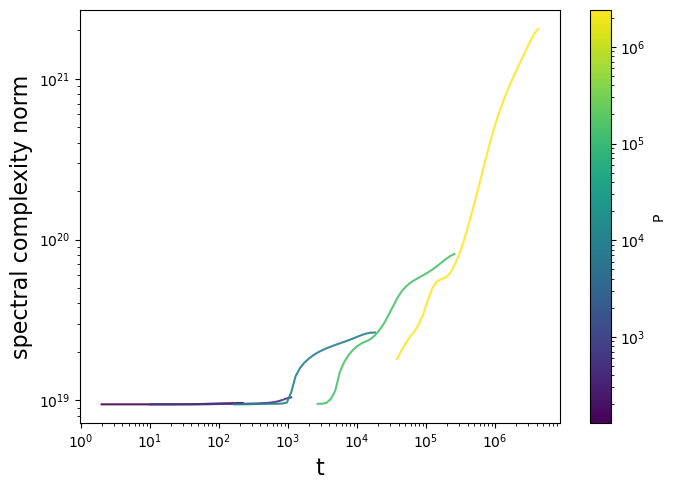

In [41]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity_no_QK",
    norm_type="time",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_6096/1309499826.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_6096/1309499826.py:274: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='L2 norm', ylabel='test error'>)

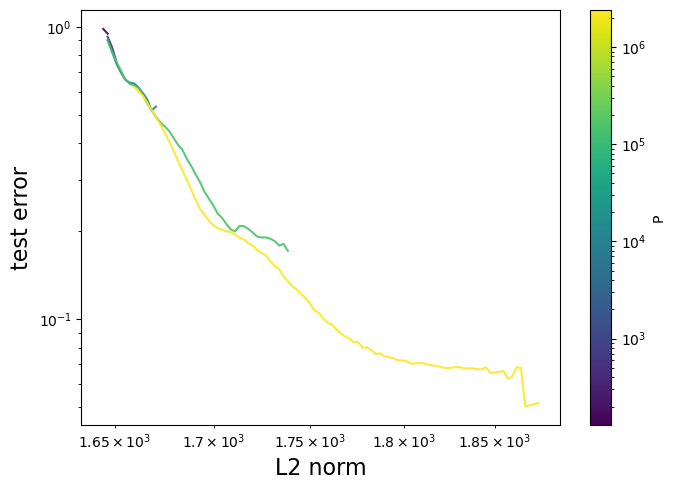

In [7]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="l2",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_6096/1309499826.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_6096/1309499826.py:274: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

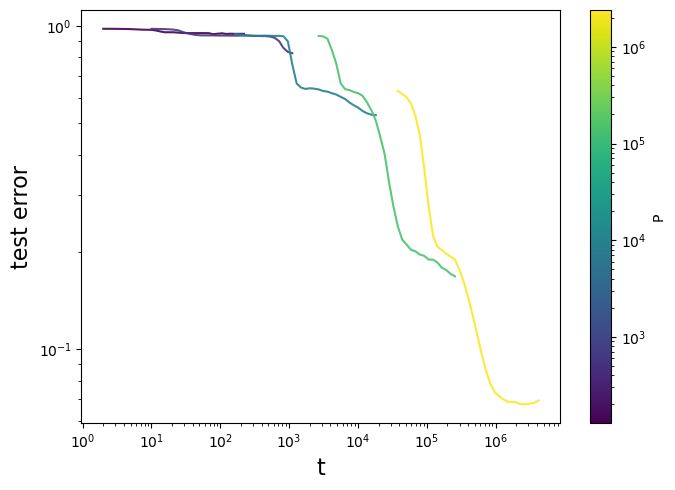

In [8]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_6096/1309499826.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_6096/1309499826.py:274: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='spectral complexity norm'>)

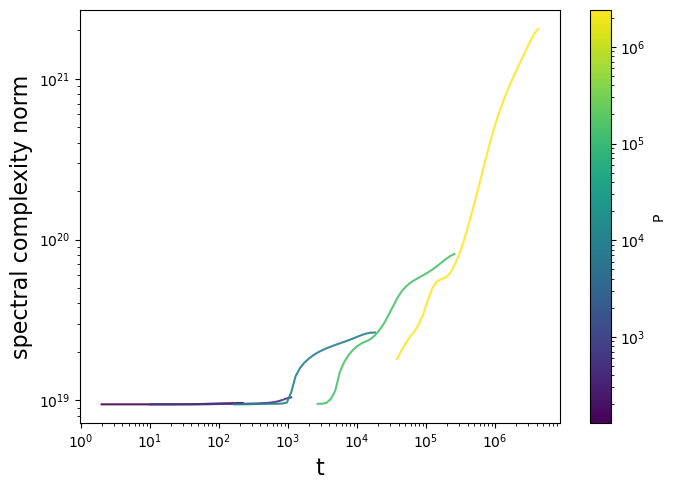

In [9]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity_no_QK",
    norm_type="time",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


# Norm study, RHM uniform

## Init scale = 0.8

### No Q,K

In [8]:
res = np.load("results/exp_base_v13.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'timestep_values', 'T_arr_timestep', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'trainacc_raw', 'trainerr_raw', 'testloss_raw', 'testacc_raw', 'err_raw', 'spectral_raw', 'spectral_no_qk_raw', 'l2_raw', 'margin_min_raw', 'margin_mean_raw', 'margin_max_raw', 'margin_std_raw', 'trainloss_timestep_raw', 'trainacc_timestep_raw', 'trainerr_timestep_raw', 'testloss_timestep_raw', 'testacc_timestep_raw', 'err_timestep_raw', 'spectral_timestep_raw', 'spectral_no_qk_timestep_raw', 'l2_timestep_raw', 'margin_min_timestep_raw', 'margin_mean_timestep_raw', 'margin_max_timestep_raw', 'margin_std_timestep_raw', 'trainloss_seeds', 'trainacc_seeds', 'trainerr_seeds', 'testloss_seeds', 'testacc_seeds', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_seeds', 'l2_seeds', 'margin_min_seeds', 'margin_mean_seeds', 'margin_max_seeds', 'margin_std_seeds', 'trainloss_seeds_timestep', 'trainacc_seeds_timestep', 'tra

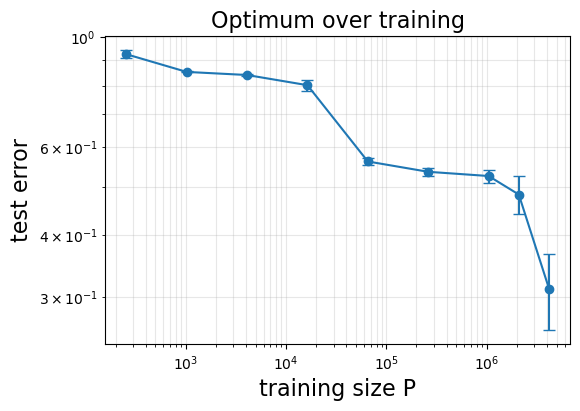

In [19]:
P = res["P_values"]
y = res["best_acc_mean"]
yerr = np.where(res["best_acc_std"] < 0, 0.0, res["best_acc_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, 1-y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training size P", fontsize=16)
plt.ylabel("test error", fontsize=16)
plt.title("Optimum over training", fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_6096/1309499826.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_6096/1309499826.py:274: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

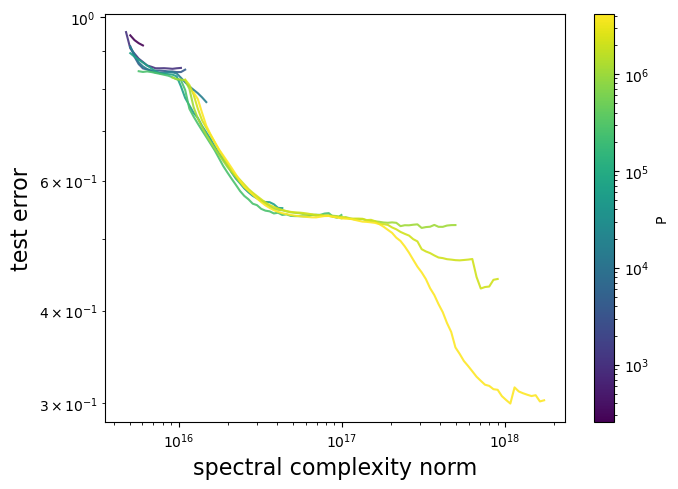

In [20]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_20079/2866105030.py:197: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_20079/2866105030.py:317: RuntimeWarning: Mean of empty slice
  mean_curve_1 = np.nanmean(interp_arr_1, axis=0)
/tmp/ipykernel_20079/2866105030.py:338: RuntimeWarning: Mean of empty slice
  mean_curve_2 = np.nanmean(interp_arr_2, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test loss / train loss'>)

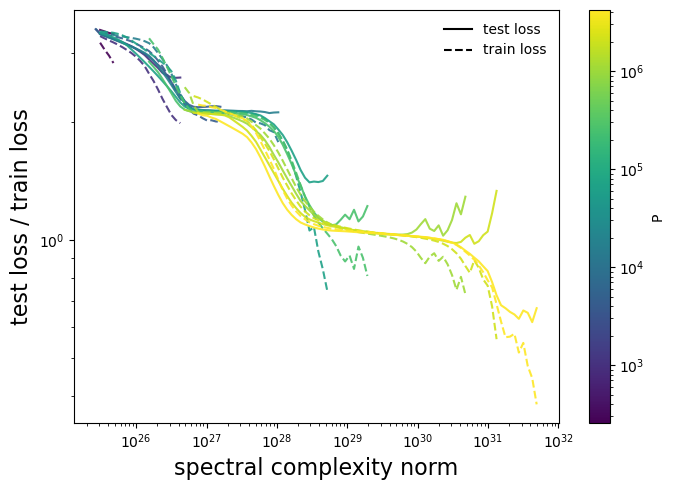

In [9]:
two_plots(
    res,
    y_plot_1 = "test_loss",
    y_plot_2 = "train_loss",
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_131966/1309499826.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_131966/1309499826.py:274: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='train loss'>)

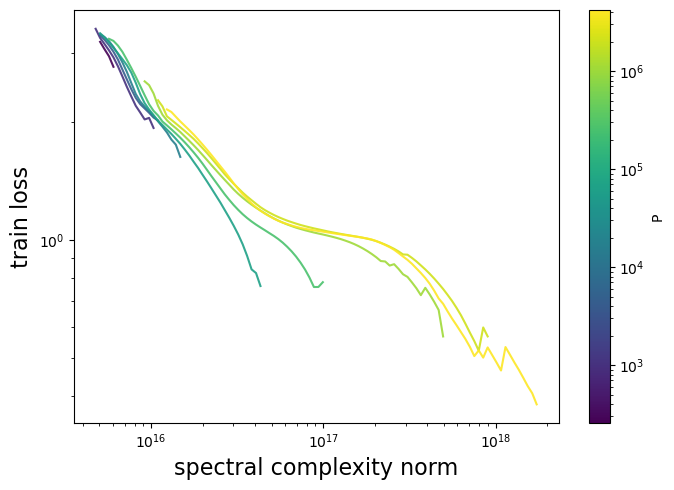

In [10]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "train_loss",
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_131966/1309499826.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_131966/1309499826.py:274: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test loss'>)

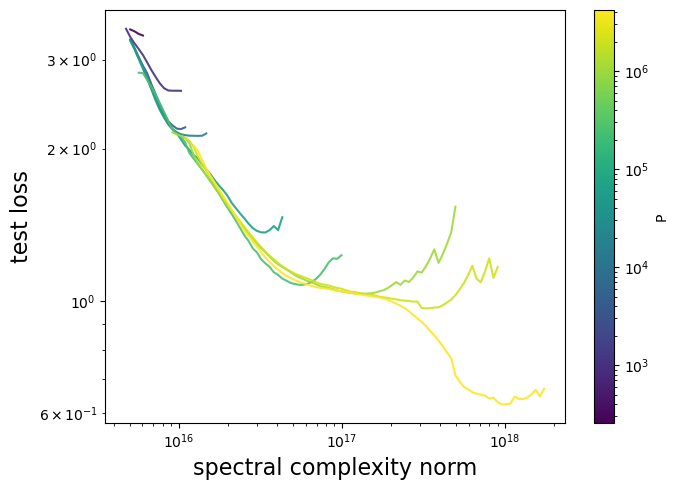

In [11]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "test_loss",
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_16723/2003608532.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_16723/2003608532.py:270: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

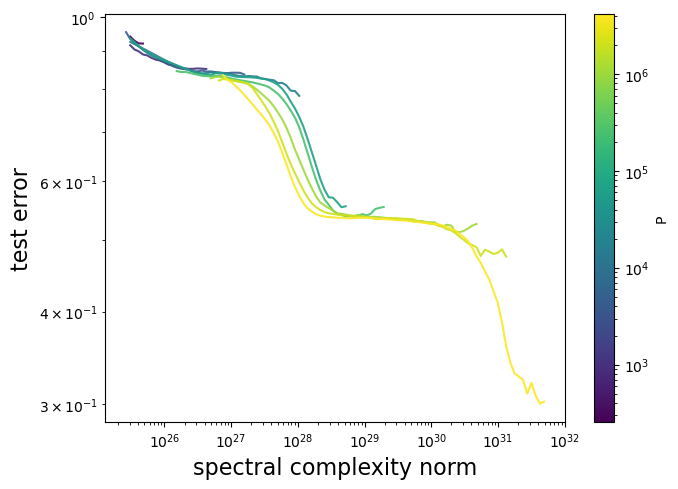

In [8]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_51774/2003608532.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_51774/2003608532.py:270: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='L2 norm', ylabel='test error'>)

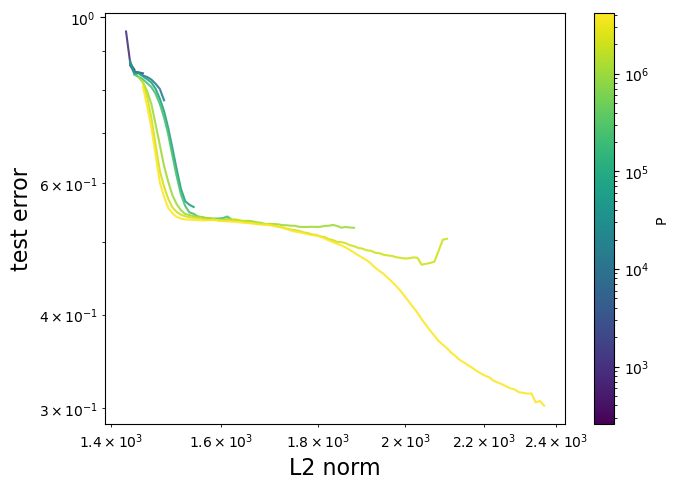

In [5]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="l2",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_5311/2003608532.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_5311/2003608532.py:270: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

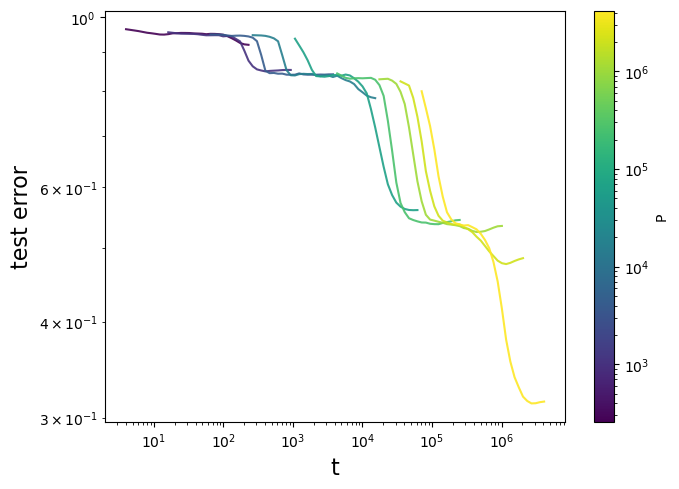

In [72]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_51774/2003608532.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_51774/2003608532.py:270: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='spectral complexity norm'>)

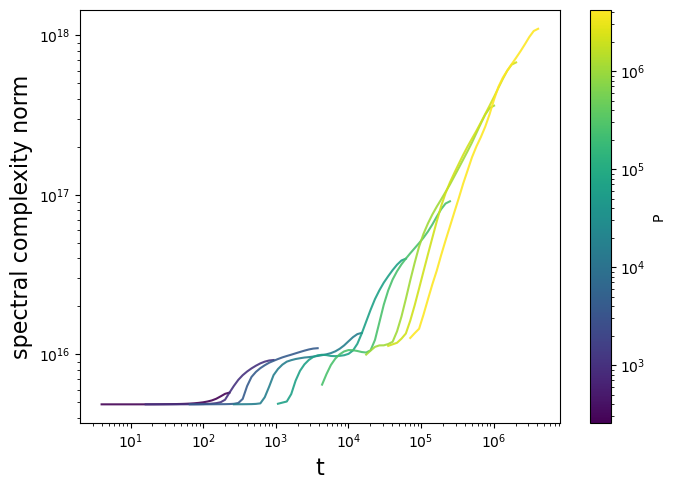

In [7]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity_no_QK",
    norm_type="time",
    xscale="log",
    yscale="log",
        average_seeds=True,
    avg_num_x=100,
)


### With Q,K

In [3]:
res = np.load("results/exp_base_v12.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_raw', 'spectral_no_qk_seeds', 'l2_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'last_saved_epoch_mean', 'last_saved_epoch_std', 'last_saved_epoch_n', 'file_index'])
P values: [    256    1024    4096   16384   65536  262144 1048576 2097152 4194304]
epochs: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47

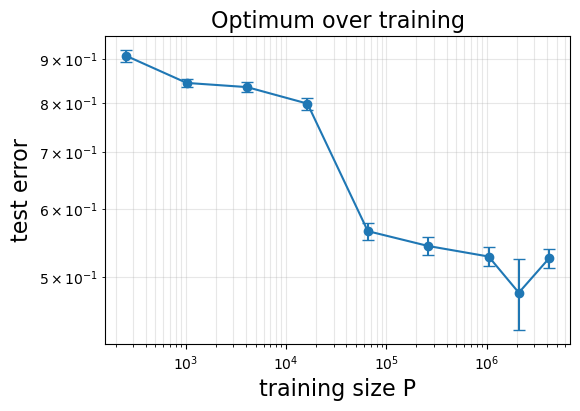

In [4]:
P = res["P_values"]
y = res["best_acc_mean"]
yerr = np.where(res["best_acc_std"] < 0, 0.0, res["best_acc_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, 1-y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training size P", fontsize=16)
plt.ylabel("test error", fontsize=16)
plt.title("Optimum over training", fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_16723/2003608532.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

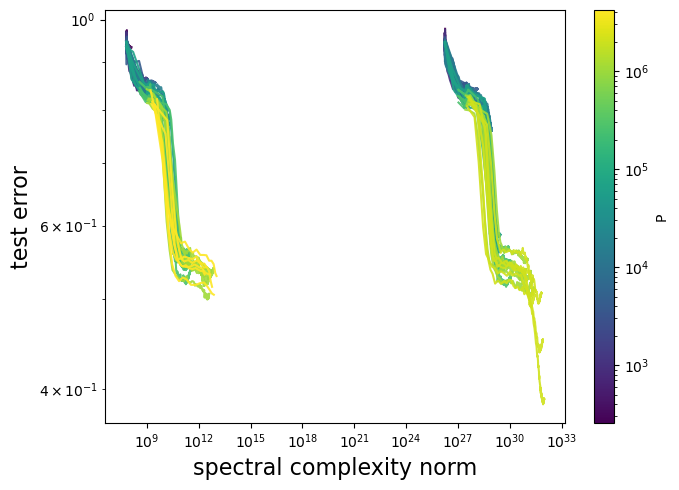

In [5]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
)


In [ ]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="l2",
    xscale="log",
    yscale="log",
)


In [ ]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
)


In [ ]:


plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity",
    norm_type="time",
    xscale="log",
    yscale="log",
)


In [ ]:


plot_err_vs_norm_all_curves(
    res,
    y_plot = "l2",
    norm_type="time",
    xscale="log",
    yscale="log",
)


## Init scale = 1.0

In [ ]:
res = np.load("results/exp_base_v10.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

In [ ]:
P = res["P_values"]
y = res["best_loss_mean"]
yerr = np.where(res["best_loss_std"] < 0, 0.0, res["best_loss_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("train size P")
plt.ylabel("best test loss")
plt.title("Blue curve")
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [ ]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
)
